## Objectif
Dans ce TP, vous allez pouvoir tester plusieurs LLMs (Mistral) et plusieurs prompts pour la traduction.




## Installation

In [1]:
# @title
! pip install mistralai
import textwrap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.3/509.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 8.2 MB/s eta 0:00:00


In [4]:
# @title
from mistralai import Mistral
api_key = "ixawMvrsAfUZnjIErMp0dUAZJyzcSwga"
client = Mistral(api_key=api_key)

nemo = "open-mistral-nemo-2407"
large = "mistral-large-2411"
mini ="ministral-3b-latest"

def generate(prompt,model):
  chat_response = client.chat.complete(
    model=model,
    messages=[{"role":"user", "content": prompt}]
  )

  response_content = chat_response.choices[0].message.content

  # Use textwrap to format the response content
  formatted_content = textwrap.fill(response_content, width=80)
  print(formatted_content)

def generate_advanced(prompt, model, temp, max_tok, top_p, freq, presence):
  chat_response = client.chat.complete(
      model=model,
      temperature=temp,      # entre 0 et 1
      max_tokens = max_tok,
      top_p = top_p,            # entre 0 et 1
      frequency_penalty=freq,  # entre -2 et 2
      presence_penalty=presence,   # entre -2 et 2
      messages=[{"role":"user", "content": prompt}]
  )

  response_content = chat_response.choices[0].message.content

  # Use textwrap to format the response content
  formatted_content = textwrap.fill(response_content, width=80)
  print(formatted_content)


## Influence du prompt

Pour cet exercice, nous utilisons le modèle **Mistral Nemo**. Il s'agit d'un modèle opensource multilingue qui supporte, entre autres, les langues suivantes : français, allemand, Espagnol, italien, portugais, russe, chinois et japonais.

Pour plus d'information sur ce modèle https://huggingface.co/mistralai/Mistral-Nemo-Base-2407

Vous trouverez aussi des informations sur les autres modèles Mistral ici:
https://docs.mistral.ai/getting-started/models

Dans la cellule ci-dessous, vous pouvez tester différents prompts pour traduire le même extrait de texte.
Vous pouvez essayer les différents prompts de Bawden et Yvon (2023) (https://aclanthology.org/2023.eamt-1.16/) ou de Jiang (2024) (https://arxiv.org/pdf/2401.05176v1), mais aussi créer vos propres prompts.

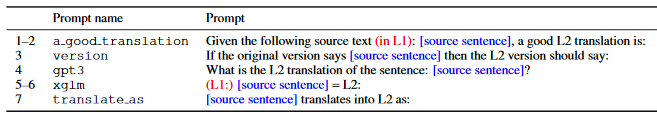

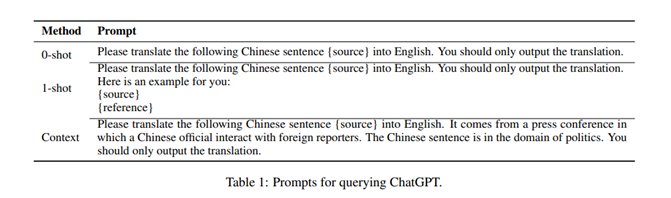

Sauvergardez l'output afin de pouvoir comparer les différents résultats.

In [9]:
text = """Copenhagen's once-industrial port has been planned to make everything – from schools and play areas to businesses and recreational spaces – accessible within five minutes.
While cruising the canals of Copenhagen in the summer of 2023, my guide pointed out Nordhavn, the city's once-industrial neighbourhood, excitedly claiming it would become the coolest new city in Europe. \
From the boat, I couldn't see much beyond a few residential buildings and lots of giant construction machinery, but, as an architect, I was interested to know more.
"""

In [10]:
prompt1 = f"EN: {text} = FR:"

prompt2 = f"""translate the following English text into French like making sure it is fluent and accurate.
Generate only the translation without comments: {text}?"""



In [11]:
generate(prompt1, nemo)

Le quartier industriel autrefois florissant de Copenhague est en train de se
transformer en un lieu où tout sera accessible à pied en cinq minutes, des
écoles et des espaces de jeux aux entreprises et aux espaces de loisirs. Lors
d'une croisière en été 2023 le long des canaux de Copenhague, mon guide m'a
montré fièrement Nordhavn, le quartier industriel de la ville, en affirmant
qu'il deviendrait la ville la plus branchée d'Europe. Depuis le bateau, je n'ai
pu voir que quelques bâtiments résidentiels et beaucoup de grosses machines de
construction, mais en tant qu'architecte, j'étais curieux d'en savoir plus.


In [12]:
generate(prompt2, nemo)

Le port autrefois industriel de Copenhague est aménagé pour rendre tout
accessible en cinq minutes, des écoles et des espaces de jeu aux entreprises et
aux espaces de loisirs. Lors d'une croisière sur les canaux de Copenhague en été
2023, mon guide m'a montré Nordhavn, le quartier industriel de la ville, en
affirmant avec enthousiasme qu'il deviendrait la nouvelle ville la plus branchée
d'Europe. Depuis le bateau, je ne voyais pas grand-chose outre quelques
bâtiments résidentiels et beaucoup de grosses machines de construction, mais en
tant qu'architecte, j'étais intéressé pour en savoir plus.


## Influence du modèle

Dans cette partie, vous pouvez modifier le modèle pour voir si cela influence le résultat de la traduction.
Vous pouvz utiliser les modèles suivants:

- **nemo** = "open-mistral-nemo-2407" (https://docs.mistral.ai/models/mistral-nemo-12b-24-07)
- **large** = "mistral-large-2411" (https://docs.mistral.ai/models/mistral-large-2-1-24-11)
- **mini** ="ministral-3b-latest" (https://docs.mistral.ai/models/ministral-3b-24-1)


In [ ]:
prompt = f"EN: {text} ?FR:"

In [ ]:
generate(prompt, large)

In [ ]:
generate(prompt, mini)

## Influence des paramètres

Dans la cellule ci-dessous, vous pouvez essayer de modifier certains paramètres comme la **température**, le **top_p**, la **pénalité de fréquence** ou la **pénalité de présence** pour observer leur influence sur le résultat final.

Pour plus d'information sur ces paramètres https://docs.mistral.ai/api/#tag/chat


In [13]:
prompt = f"EN: {text} ?FR:"

temperature=0.3      # entre 0 et 1
max_tokens = 500
top_p = 0.1           # entre 0 et 1
frequency_penalty=0  # entre -2 et 2
presence_penalty=0    # entre -2 et 2

generate_advanced(prompt, nemo, temperature, max_tokens, top_p, frequency_penalty, presence_penalty)

Le quartier industriel autrefois florissant de Copenhague est en train de se
transformer en un lieu où tout sera accessible à pied en cinq minutes, des
écoles et des espaces de jeux aux entreprises et aux espaces de loisirs. Lors
d'une croisière en été 2023 sur les canaux de Copenhague, mon guide m'a montré
fièrement Nordhavn, le quartier industriel de la ville, en affirmant qu'il
deviendrait la ville la plus branchée d'Europe. Depuis le bateau, je n'ai vu que
quelques bâtiments résidentiels et beaucoup de grosses machines de construction,
mais en tant qu'architecte, j'étais curieux d'en savoir plus.
